# 🚕 NYC Taxi — Exploration & Audit Qualité
**Projet Data Pipeline — Analyse de l'échantillon RAW**

Ce notebook explore les données brutes chargées dans Snowflake et identifie les problèmes de qualité à traiter dans la couche STAGING.

## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector
import os
import warnings
warnings.filterwarnings('ignore')

# Style des graphiques
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Imports OK')

✅ Imports OK


## 1. Connexion Snowflake & Chargement

In [2]:
load_dotenv()

conn = snowflake.connector.connect(
    account   = os.getenv('SNOWFLAKE_ACCOUNT'),
    user      = os.getenv('SNOWFLAKE_USER'),
    password  = os.getenv('SNOWFLAKE_PASSWORD'),
    warehouse = os.getenv('SNOWFLAKE_WAREHOUSE', 'NYC_TAXI_WH'),
    database  = os.getenv('SNOWFLAKE_DATABASE',  'NYC_TAXI_DB'),
    schema    = os.getenv('SNOWFLAKE_SCHEMA',     'RAW'),
    role      = os.getenv('SNOWFLAKE_ROLE',       'SYSADMIN')
)

print('✅ Connecté à Snowflake')

✅ Connecté à Snowflake


In [3]:
# Charger un échantillon représentatif (100k lignes pour l'exploration)
# Ajuster SAMPLE_SIZE selon les ressources disponibles
SAMPLE_SIZE = 100_000

query = f"""
    SELECT *
    FROM NYC_TAXI_DB.RAW.yellow_taxi_trips
    SAMPLE ({SAMPLE_SIZE} ROWS)
"""

df = pd.read_sql(query, conn)
df.columns = df.columns.str.lower()

print(f'✅ Échantillon chargé : {len(df):,} lignes × {len(df.columns)} colonnes')
df.head()

✅ Échantillon chargé : 100,000 lignes × 22 colonnes


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,cbd_congestion_fee,_loaded_at,_source_file
0,2,2024-05-29 00:26:54,2024-05-29 00:40:30,1.0,6.17,1.0,N,170,42,1,...,0.5,6.22,0.00,1.0,37.32,2.5,0.0,NaN,2026-06-02 05:07:32.980,yellow_tripdata_2024-05.parquet
1,1,2025-03-05 14:17:17,2025-03-05 14:34:42,1.0,1.40,1.0,N,141,161,1,...,0.5,3.80,0.00,1.0,22.75,2.5,0.0,0.75,2026-06-02 05:13:24.455,yellow_tripdata_2025-03.parquet
2,2,2024-02-29 11:35:20,2024-02-29 11:50:01,1.0,1.87,1.0,N,239,163,1,...,0.5,4.72,0.00,1.0,23.62,2.5,0.0,NaN,2026-06-02 05:05:48.085,yellow_tripdata_2024-02.parquet
3,2,2024-09-29 14:41:08,2024-09-29 14:58:35,1.0,2.89,1.0,N,261,68,1,...,0.5,4.62,0.00,1.0,27.72,2.5,0.0,NaN,2026-06-02 05:09:43.112,yellow_tripdata_2024-09.parquet
4,1,2024-02-26 15:37:22,2024-02-26 16:28:38,1.0,10.90,99.0,N,107,21,1,...,0.5,0.00,6.94,1.0,46.94,0.0,0.0,NaN,2026-06-02 05:05:48.085,yellow_tripdata_2024-02.parquet


## 2. Vue d'ensemble du dataset

In [4]:
# Volume total dans Snowflake
total_query = "SELECT COUNT(*) AS total FROM NYC_TAXI_DB.RAW.yellow_taxi_trips"
total = pd.read_sql(total_query, conn).iloc[0, 0]
print(f'📊 Volume total dans Snowflake : {total:,} lignes')
print(f'📊 Échantillon analysé         : {len(df):,} lignes ({len(df)/total*100:.2f}%)')
print(f'📊 Colonnes                    : {list(df.columns)}')

📊 Volume total dans Snowflake : 52,367,746 lignes
📊 Échantillon analysé         : 100,000 lignes (0.19%)
📊 Colonnes                    : ['vendorid', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'ratecodeid', 'store_and_fwd_flag', 'pulocationid', 'dolocationid', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'cbd_congestion_fee', '_loaded_at', '_source_file']


In [5]:
# Types et aperçu général
print('=== TYPES DE DONNÉES ===')
print(df.dtypes)
print()
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe(include='all').T

=== TYPES DE DONNÉES ===
vendorid                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
ratecodeid                      float64
store_and_fwd_flag                  str
pulocationid                      int64
dolocationid                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
cbd_congestion_fee              float64
_loaded_at               datetime64[us]
_source_file                        str
dtype: object

=== STATISTIQUES DESCRIPTIVES ===


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
vendorid,100000.0,NaN,NaN,NaN,1.77232,1.0,2.0,2.0,2.0,7.0,0.440163
tpep_pickup_datetime,100000,NaN,NaN,NaN,2024-08-26 22:10:20.209820,2002-12-31 22:17:10,2024-05-07 06:55:36.500000,2024-09-08 00:48:27,2024-12-13 14:34:37,2025-03-31 23:55:51,NaN
tpep_dropoff_datetime,100000,NaN,NaN,NaN,2024-08-26 22:27:11.604659,2002-12-31 22:42:24,2024-05-07 07:04:47,2024-09-08 00:54:37,2024-12-13 14:57:11.250000,2025-04-01 00:16:33,NaN
passenger_count,88772.0,NaN,NaN,NaN,1.319448,0.0,1.0,1.0,1.0,6.0,0.789166
trip_distance,100000.0,NaN,NaN,NaN,4.485441,0.0,1.01,1.74,3.31,117315.2,370.998492
ratecodeid,88772.0,NaN,NaN,NaN,2.437548,1.0,1.0,1.0,1.0,99.0,11.426803
store_and_fwd_flag,88772,2,N,88349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pulocationid,100000.0,NaN,NaN,NaN,164.43208,1.0,132.0,161.0,233.0,265.0,64.306699
dolocationid,100000.0,NaN,NaN,NaN,163.09651,1.0,113.0,162.0,234.0,265.0,69.667599
payment_type,100000.0,NaN,NaN,NaN,1.08874,0.0,1.0,1.0,1.0,4.0,0.661566


## 3. Audit Qualité — Valeurs Manquantes

=== VALEURS MANQUANTES PAR COLONNE ===
                      Valeurs manquantes  % manquant
cbd_congestion_fee                 78567       78.57
ratecodeid                         11228       11.23
airport_fee                        11228       11.23
congestion_surcharge               11228       11.23
store_and_fwd_flag                 11228       11.23
passenger_count                    11228       11.23


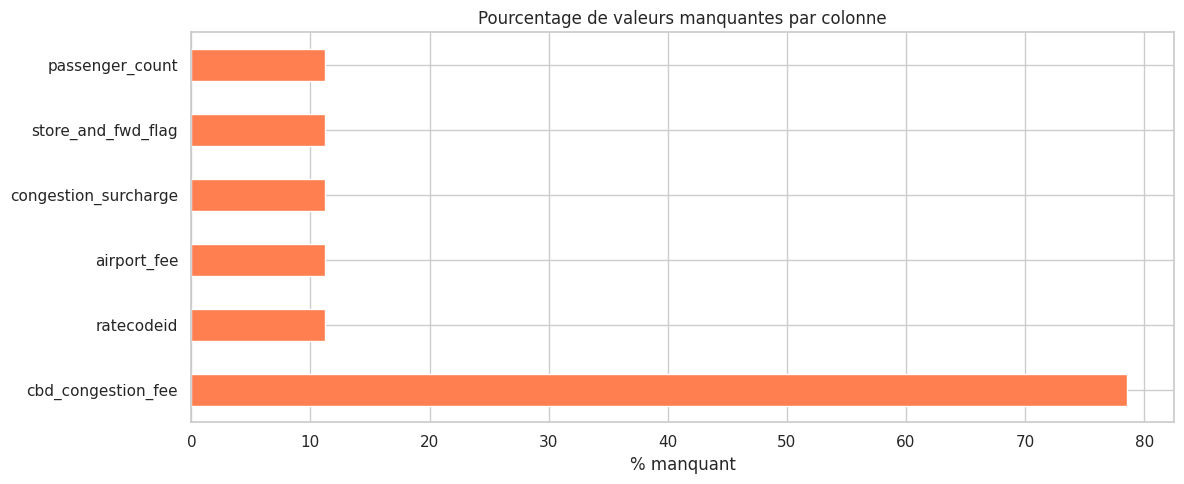

In [6]:
# Calcul des nulls par colonne
null_counts  = df.isnull().sum()
null_percent = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Valeurs manquantes': null_counts,
    '% manquant'        : null_percent
}).sort_values('% manquant', ascending=False)

print('=== VALEURS MANQUANTES PAR COLONNE ===')
print(null_df[null_df['Valeurs manquantes'] > 0])

# Visualisation
cols_with_nulls = null_df[null_df['% manquant'] > 0]
if not cols_with_nulls.empty:
    ax = cols_with_nulls['% manquant'].plot(kind='barh', color='coral')
    plt.title('Pourcentage de valeurs manquantes par colonne')
    plt.xlabel('% manquant')
    plt.tight_layout()
    plt.show()
else:
    print('✅ Aucune valeur manquante détectée')

## 4. Audit Qualité — Montants Négatifs

In [7]:
colonnes_montants = ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount',
                     'extra', 'mta_tax', 'improvement_surcharge']

print('=== MONTANTS NÉGATIFS ===')
for col in colonnes_montants:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        pct   = n_neg / len(df) * 100
        if n_neg > 0:
            print(f'⚠️  {col:<30} : {n_neg:>6,} lignes ({pct:.3f}%)')
        else:
            print(f'✅ {col:<30} : OK')

=== MONTANTS NÉGATIFS ===
⚠️  fare_amount                    :  2,390 lignes (2.390%)
⚠️  tip_amount                     :      2 lignes (0.002%)
⚠️  tolls_amount                   :    137 lignes (0.137%)
⚠️  total_amount                   :  1,497 lignes (1.497%)
⚠️  extra                          :    734 lignes (0.734%)
⚠️  mta_tax                        :  1,419 lignes (1.419%)
⚠️  improvement_surcharge          :  1,482 lignes (1.482%)


In [8]:
# Inspecter les lignes avec montants négatifs
df_negatifs = df[df['fare_amount'] < 0]
print(f'Lignes avec fare_amount négatif : {len(df_negatifs)}')
print()
print('Exemple de lignes problématiques :')
df_negatifs[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance',
             'fare_amount', 'total_amount', 'payment_type']].head(10)

Lignes avec fare_amount négatif : 2390

Exemple de lignes problématiques :


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,payment_type
27,2024-03-30 23:50:32,2024-03-31 00:00:18,1.61,-10.70,-15.70,2
34,2024-06-21 21:19:48,2024-06-21 21:30:13,1.53,-11.40,-16.40,4
54,2025-03-20 23:45:13,2025-03-20 23:49:48,0.58,-1.50,5.00,0
92,2024-10-31 07:36:48,2024-10-31 07:57:33,3.76,-0.44,3.56,0
122,2025-03-21 19:02:08,2025-03-21 19:18:05,2.01,-4.75,4.00,0
144,2025-03-26 09:21:09,2025-03-26 09:43:34,2.08,-4.75,3.88,0
153,2024-06-30 17:55:23,2024-06-30 18:02:41,1.55,-9.30,-13.30,2
167,2025-02-19 19:36:50,2025-02-19 19:43:53,0.82,-7.90,-14.40,4
182,2025-03-28 05:54:11,2025-03-28 06:07:28,1.75,-4.75,4.78,0
207,2025-03-13 23:20:41,2025-03-13 23:28:23,1.16,-4.75,3.00,0


In [10]:
# Vérifier si les négatifs ont un doublon positif (remboursements)
# Même datetime + même distance = paire remboursement/original
df_neg = df[df['fare_amount'] < 0].copy()
df_pos = df[df['fare_amount'] > 0].copy()

merge_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'pulocationid']
doublons = df_neg.merge(df_pos, on=merge_cols, suffixes=('_neg', '_pos'))

print(f'Paires remboursement/original détectées : {len(doublons)}')
print('Exemple de doublons :', doublons[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'pulocationid',
                                  'fare_amount_neg', 'fare_amount_pos']])
if len(doublons) > 0:
    print('⚠️  Ces lignes sont des remboursements avec doublon positif — à supprimer dans STAGING')

Paires remboursement/original détectées : 2
Exemple de doublons :   tpep_pickup_datetime tpep_dropoff_datetime  trip_distance  pulocationid  \
0  2024-07-30 11:21:45   2024-07-30 11:45:59           2.28           239   
1  2025-01-01 16:02:34   2025-01-01 16:05:00           0.45           237   

   fare_amount_neg  fare_amount_pos  
0            -21.9             21.9  
1             -5.1              5.1  
⚠️  Ces lignes sont des remboursements avec doublon positif — à supprimer dans STAGING


## 5. Audit Qualité — Trajets Incohérents

In [11]:
df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['duration_minutes']      = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

checks = {
    'Durée négative ou nulle'        : (df['duration_minutes'] <= 0).sum(),
    'Durée > 5h (300 min)'           : (df['duration_minutes'] > 300).sum(),
    'Distance = 0'                   : (df['trip_distance'] == 0).sum(),
    'Distance > 200 miles'           : (df['trip_distance'] > 200).sum(),
    'passenger_count = 0'            : (df['passenger_count'] == 0).sum(),
    'passenger_count > 8'            : (df['passenger_count'] > 8).sum(),
    'passenger_count nul'            : df['passenger_count'].isnull().sum(),
    'PU = DO (même zone)'            : (df['pulocationid'] == df['dolocationid']).sum(),
}

print('=== ANOMALIES DÉTECTÉES ===')
for label, count in checks.items():
    pct    = count / len(df) * 100
    status = '⚠️ ' if count > 0 else '✅'
    print(f'{status} {label:<40} : {count:>6,} ({pct:.3f}%)')

=== ANOMALIES DÉTECTÉES ===
⚠️  Durée négative ou nulle                  :     89 (0.089%)
⚠️  Durée > 5h (300 min)                     :     38 (0.038%)
⚠️  Distance = 0                             :  1,999 (1.999%)
⚠️  Distance > 200 miles                     :      1 (0.001%)
⚠️  passenger_count = 0                      :    904 (0.904%)
✅ passenger_count > 8                      :      0 (0.000%)
⚠️  passenger_count nul                      : 11,228 (11.228%)
⚠️  PU = DO (même zone)                      :  5,135 (5.135%)


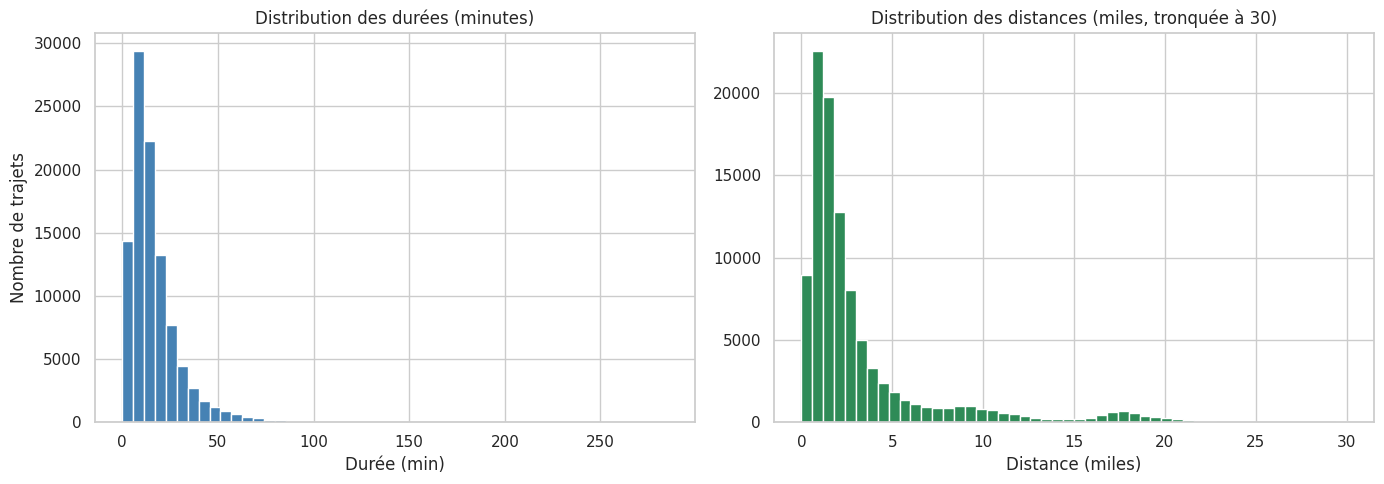

In [12]:
# Distribution des durées
durations_valid = df[(df['duration_minutes'] > 0) & (df['duration_minutes'] < 300)]['duration_minutes']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(durations_valid, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des durées (minutes)')
axes[0].set_xlabel('Durée (min)')
axes[0].set_ylabel('Nombre de trajets')

axes[1].hist(df['trip_distance'].clip(0, 30), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution des distances (miles, tronquée à 30)')
axes[1].set_xlabel('Distance (miles)')

plt.tight_layout()
plt.show()

## 6. Audit Qualité — Colonne CBD_CONGESTION_FEE

In [25]:
if 'cbd_congestion_fee' in df.columns:
    n_total    = len(df)
    n_null     = df['cbd_congestion_fee'].isnull().sum()
    n_zero     = (df['cbd_congestion_fee'] == 0).sum()
    n_nonzero  = (df['cbd_congestion_fee'].notna() & (df['cbd_congestion_fee'] != 0)).sum()
    pct_null   = n_null   / n_total * 100
    pct_zero   = n_zero   / n_total * 100
    pct_nonzero= n_nonzero/ n_total * 100

    print('=== COLONNE CBD_CONGESTION_FEE ===')
    print(f'Total lignes          : {n_total:,}')
    print(f'Valeurs nulles        : {n_null:,} ({pct_null:.1f}%)')
    print(f'Valeurs = 0           : {n_zero:,} ({pct_zero:.1f}%)')
    print(f'Valeurs non-null != 0 : {n_nonzero:,} ({pct_nonzero:.1f}%)')
    print()

    # Vérification que les 3 catégories s'additionnent bien
    assert n_null + n_zero + n_nonzero == n_total, "❌ Erreur : les catégories ne s'additionnent pas correctement"
    print('✅ Vérification OK : null + zero + nonzero = total')
    print()

    if pct_null > 50:
        print('⚠️  Colonne majoritairement vide')
        print('   → Contexte : CBD Congestion Pricing actif depuis janvier 2025')
        print('   → Décision : COALESCE(cbd_congestion_fee, 0) dans STAGING')

    # Distribution des valeurs non nulles
    if n_nonzero > 0:
        print()
        print('Distribution des valeurs non-nulles :')
        print(df['cbd_congestion_fee'].dropna().value_counts().sort_index().to_string())
else:
    print('Colonne cbd_congestion_fee absente du dataset')

=== COLONNE CBD_CONGESTION_FEE ===
Total lignes          : 100,000
Valeurs nulles        : 78,567 (78.6%)
Valeurs = 0           : 6,155 (6.2%)
Valeurs non-null != 0 : 15,278 (15.3%)

✅ Vérification OK : null + zero + nonzero = total

⚠️  Colonne majoritairement vide
   → Contexte : CBD Congestion Pricing actif depuis janvier 2025
   → Décision : COALESCE(cbd_congestion_fee, 0) dans STAGING

Distribution des valeurs non-nulles :
cbd_congestion_fee
-0.75      157
 0.00     6155
 0.75    15120
 1.25        1


## 7. Analyse des Doublons

In [14]:
cles_doublon = ['tpep_pickup_datetime', 'tpep_dropoff_datetime',
                'pulocationid', 'dolocationid', 'trip_distance', 'fare_amount']

n_doublons = df.duplicated(subset=cles_doublon).sum()
pct        = n_doublons / len(df) * 100

print(f'Doublons exacts détectés : {n_doublons:,} ({pct:.3f}%)')

if n_doublons > 0:
    print()
    print('Exemples de doublons :')
    df[df.duplicated(subset=cles_doublon, keep=False)].sort_values(cles_doublon).head(10)

Doublons exacts détectés : 0 (0.000%)


## 8. Analyse des Distributions & Outliers

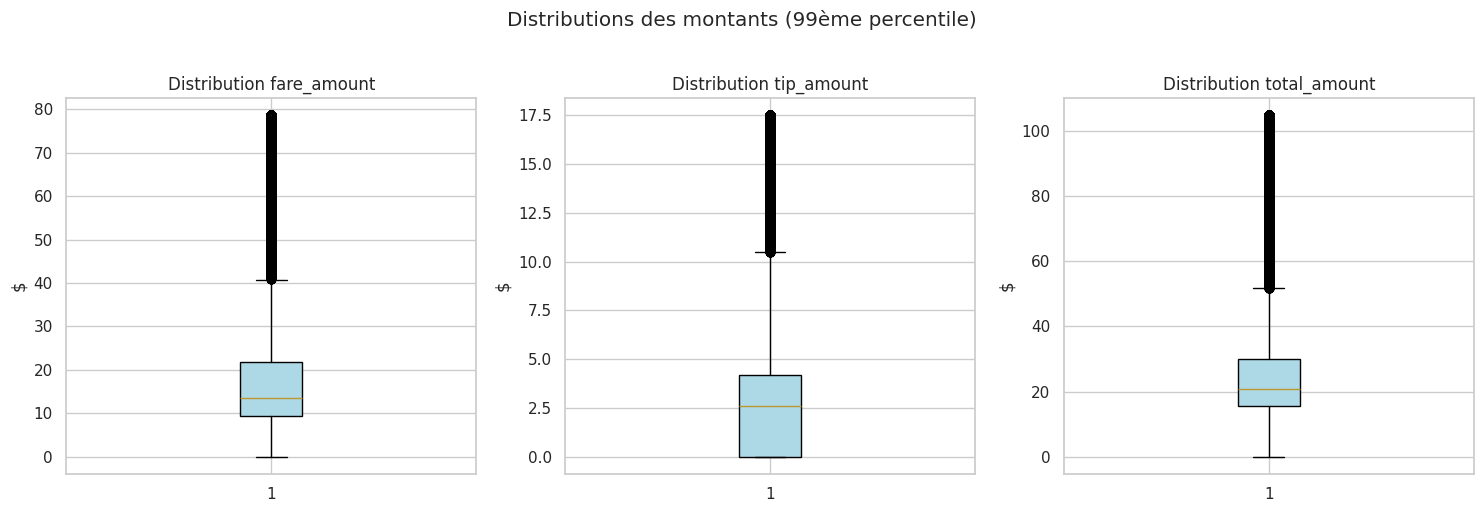

In [18]:
# Boxplots des montants
cols_plot = ['fare_amount', 'tip_amount', 'total_amount']
df_plot   = df[cols_plot].clip(lower=0, upper=df[cols_plot].quantile(0.99), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cols_plot):
    ax.boxplot(df_plot[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(f'Distribution {col}')
    ax.set_ylabel('$')

plt.suptitle('Distributions des montants (99ème percentile)', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Percentiles clés pour définir les seuils de nettoyage
cols_num = ['fare_amount', 'trip_distance', 'duration_minutes', 'total_amount', 'tip_amount']
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]

print('=== PERCENTILES CLÉS (aide à définir les seuils de nettoyage) ===')
df[cols_num].quantile(percentiles).T

=== PERCENTILES CLÉS (aide à définir les seuils de nettoyage) ===


,0.01,0.05,0.25,0.50,0.75,0.95,0.99,1.00
fare_amount,-8.6000,5.100000,9.300000,13.50,21.900000,62.4800,78.600000,500.000000
trip_distance,0.0000,0.420000,1.010000,1.74,3.310000,13.6000,19.930000,117315.200000
duration_minutes,0.5165,3.433333,7.766667,12.80,20.666667,42.5675,68.900667,1439.333333
total_amount,-13.3000,10.460000,15.700000,20.90,30.100000,80.9400,104.650400,502.750000
tip_amount,0.0000,0.000000,0.000000,2.58,4.200000,11.2600,17.500000,220.000000


## 9. Analyse Temporelle

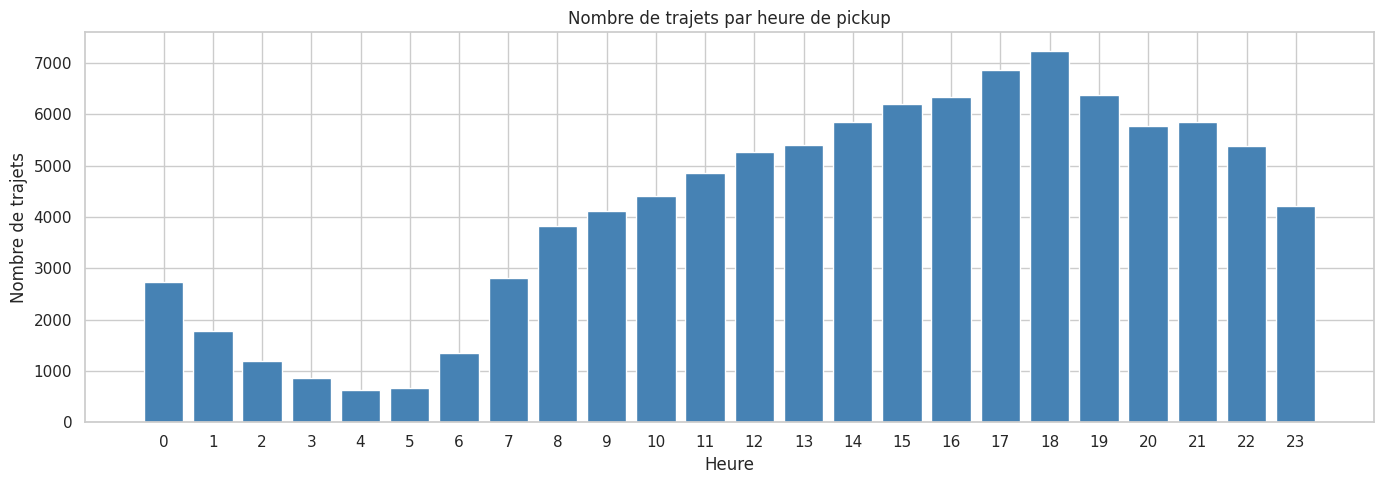

In [20]:
# Répartition par heure de la journée
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

hourly = df.groupby('pickup_hour').size().reset_index(name='nb_trajets')

plt.figure(figsize=(14, 5))
plt.bar(hourly['pickup_hour'], hourly['nb_trajets'], color='steelblue', edgecolor='white')
plt.title('Nombre de trajets par heure de pickup')
plt.xlabel('Heure')
plt.ylabel('Nombre de trajets')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [21]:
# Répartition par mois source
if '_source_file' in df.columns:
    source_counts = df['_source_file'].value_counts().sort_index()
    print('=== RÉPARTITION PAR FICHIER SOURCE ===')
    print(source_counts.to_string())

=== RÉPARTITION PAR FICHIER SOURCE ===
_source_file
yellow_tripdata_2024-01.parquet    5208
yellow_tripdata_2024-02.parquet    5653
yellow_tripdata_2024-03.parquet    7089
yellow_tripdata_2024-04.parquet    5447
yellow_tripdata_2024-05.parquet    7539
yellow_tripdata_2024-06.parquet    5966
yellow_tripdata_2024-07.parquet    5851
yellow_tripdata_2024-08.parquet    5572
yellow_tripdata_2024-09.parquet    7422
yellow_tripdata_2024-10.parquet    7637
yellow_tripdata_2024-11.parquet    8115
yellow_tripdata_2024-12.parquet    7068
yellow_tripdata_2025-01.parquet    7710
yellow_tripdata_2025-02.parquet    6507
yellow_tripdata_2025-03.parquet    7216


## 10. Analyse des Modes de Paiement & VendorID

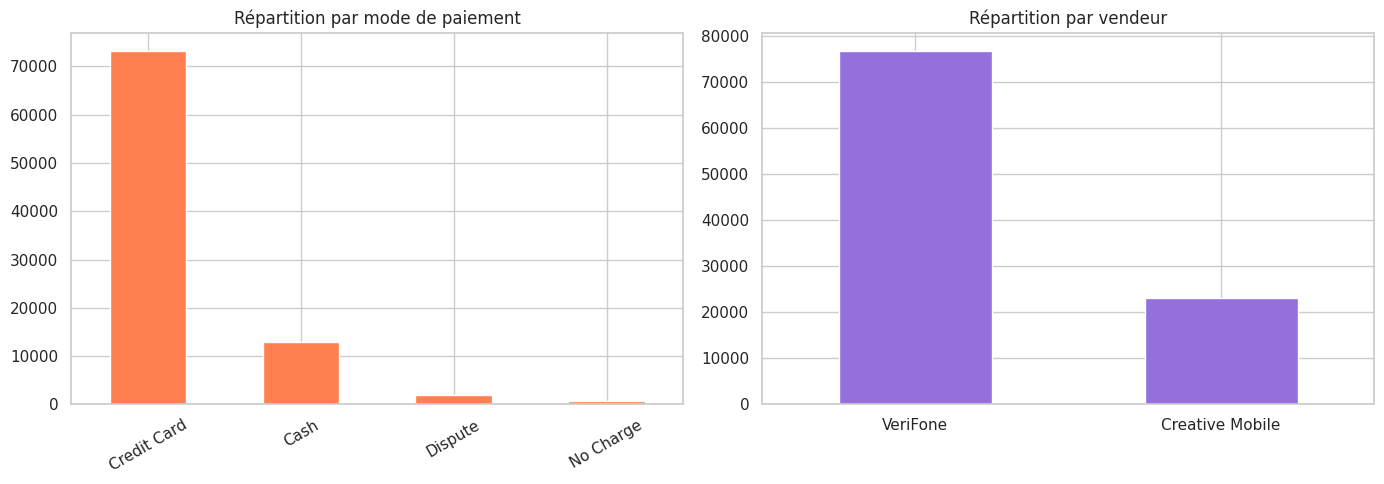

In [22]:
# Mapping des codes
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
vendor_map  = {1: 'Creative Mobile', 2: 'VeriFone'}

df['payment_label'] = df['payment_type'].map(payment_map)
df['vendor_label']  = df['vendorid'].map(vendor_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['payment_label'].value_counts().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Répartition par mode de paiement')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['vendor_label'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Répartition par vendeur')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 11. Récapitulatif — Règles de Nettoyage pour STAGING

In [ ]:
# Calcul du taux de rejet estimé
masque_valide = (
    (df['fare_amount']      >= 0) &
    (df['total_amount']     >= 0) &
    (df['tip_amount']       >= 0) &
    (df['trip_distance']    >  0) &
    (df['trip_distance']    <  200) &
    (df['duration_minutes'] >  0) &
    (df['duration_minutes'] <= 300) &
    (df['passenger_count']  >= 1) &
    (df['passenger_count']  <= 8) &
    df['pulocationid'].notna() &
    df['dolocationid'].notna()
)

n_valid  = masque_valide.sum()
n_rejete = len(df) - n_valid
pct_ok   = n_valid / len(df) * 100

print('=' * 55)
print('  RÉCAPITULATIF AUDIT QUALITÉ')
print('=' * 55)
print(f'  Lignes analysées    : {len(df):>10,}')
print(f'  Lignes valides      : {n_valid:>10,} ({pct_ok:.1f}%)')
print(f'  Lignes à rejeter    : {n_rejete:>10,} ({100-pct_ok:.1f}%)')
print()
print('  RÈGLES À APPLIQUER DANS stg_yellow_trips.sql :')
print('  ✅ fare_amount >= 0')
print('  ✅ total_amount >= 0')
print('  ✅ tip_amount >= 0')
print('  ✅ trip_distance BETWEEN 0.01 AND 200')
print('  ✅ duration_minutes BETWEEN 1 AND 300')
print('  ✅ passenger_count BETWEEN 1 AND 8')
print('  ✅ pulocationid IS NOT NULL')
print('  ✅ dolocationid IS NOT NULL')
print('  ✅ cbdcongestion_fee >= 0 (après COALESCE)')
print('=' * 55)

  RÉCAPITULATIF AUDIT QUALITÉ
  Lignes analysées    :    100,000
  Lignes valides      :     85,256 (85.3%)
  Lignes à rejeter    :     14,744 (14.7%)

  RÈGLES À APPLIQUER DANS stg_yellow_trips.sql :
  ✅ fare_amount >= 0
  ✅ total_amount >= 0
  ✅ tip_amount >= 0
  ✅ trip_distance BETWEEN 0.01 AND 200
  ✅ duration_minutes BETWEEN 1 AND 300
  ✅ passenger_count BETWEEN 1 AND 8
  ✅ pulocationid IS NOT NULL
  ✅ dolocationid IS NOT NULL
  ⚠️  Exclure colonne CBD_CONGESTION_FEE (vide)


In [ ]:
conn.close()
print('🔌 Connexion Snowflake fermée')